In [1]:
# Install the ART library (provides adversarial attacks)
!pip install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.9 MB/s eta 0:00:00


In [2]:
# Import libraries
import tensorflow
import numpy as np
import matplotlib.pyplot as plt
import os
from os import listdir
import cv2
import natsort
from sklearn.model_selection import train_test_split

# Print the version of tensorflow and keras
print("TensorFlow version:{}".format(tensorflow.__version__))

TensorFlow version:2.19.0


In [3]:
# Download the dataset
!wget https://www.idahofallshighered.org/vakanski/Codes_Data/imagenette2.zip

--2026-01-17 02:16:24--  https://www.idahofallshighered.org/vakanski/Codes_Data/imagenette2.zip
Resolving www.idahofallshighered.org (www.idahofallshighered.org)... 50.6.2.30
Connecting to www.idahofallshighered.org (www.idahofallshighered.org)|50.6.2.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 106722829 (102M) [application/zip]
Saving to: ‘imagenette2.zip’

imagenette2.zip     100%[===================>] 101.78M  13.3MB/s    in 9.4s    

2026-01-17 02:16:35 (10.9 MB/s) - ‘imagenette2.zip’ saved [106722829/106722829]



In [4]:
# Uncompress the dataset
!unzip -uq 'imagenette2.zip' -d 'sample_data/'

In [5]:
# Function to load the images and the labels from the dataset
def load_images_and_labels(directory):

    imgs_list = []
    labels_list = []

    # List of all subfolders in the directory
    subfolders_list_1 = listdir(directory)
    # Make sure that the subfolders are sorted
    subfolders_list = natsort.natsorted(subfolders_list_1)

    # Assign a label to each folder with images (0 to the first folder)
    lab = 0
    for subfolder_name in subfolders_list:
            sub_dir_path = directory + '/' + subfolder_name

            # Read the images as numpy arrays
            imagesList = listdir(sub_dir_path)
            for i in range(len(imagesList)):
              tmp_img = cv2.imread(os.path.join(sub_dir_path, imagesList[i]))
              # Resize all images to 128 x 128 pixels
              resized_img = cv2.resize(tmp_img, (128, 128))
              img_arr = np.array(resized_img)
              imgs_list.append(img_arr/255.)
              labels_list.append(lab)
            lab += 1

    # Convert the lists to numpy arrays
    imgs = np.asarray(imgs_list)
    labels = np.asarray(labels_list)

    return imgs, labels

# Use the above function to load the training and test datasets
train_images, train_labels = load_images_and_labels('sample_data/imagenette2/train')
test_and_val_images, test_and_val_labels = load_images_and_labels('sample_data/imagenette2/val')

In [6]:
# Split into test and validation sets
test_images, val_images, test_labels, val_labels = train_test_split(test_and_val_images, test_and_val_labels, test_size=0.4, random_state=12)

In [7]:
# Display the shapes of train, validation, and test datasets
print('Images train shape: {} - Labels train shape: {}'.format(train_images.shape, train_labels.shape))
print('Images validation shape: {} - Labels validation shape: {}'.format(val_images.shape, val_labels.shape))
print('Images test shape: {} - Labels test shape: {}'.format(test_images.shape, test_labels.shape))

# Display the range of images (to make sure they are in the [0, 1] range)
print('\nMax pixel value', np.max(train_images))
print('Min pixel value', np.min(train_images))
print('Average pixel value', np.mean(train_images))
print('Data type', train_images[0].dtype)

Images train shape: (9469, 128, 128, 3) - Labels train shape: (9469,)
Images validation shape: (1570, 128, 128, 3) - Labels validation shape: (1570,)
Images test shape: (2355, 128, 128, 3) - Labels test shape: (2355,)

Max pixel value 1.0
Min pixel value 0.0
Average pixel value 0.44966878195890525
Data type float64


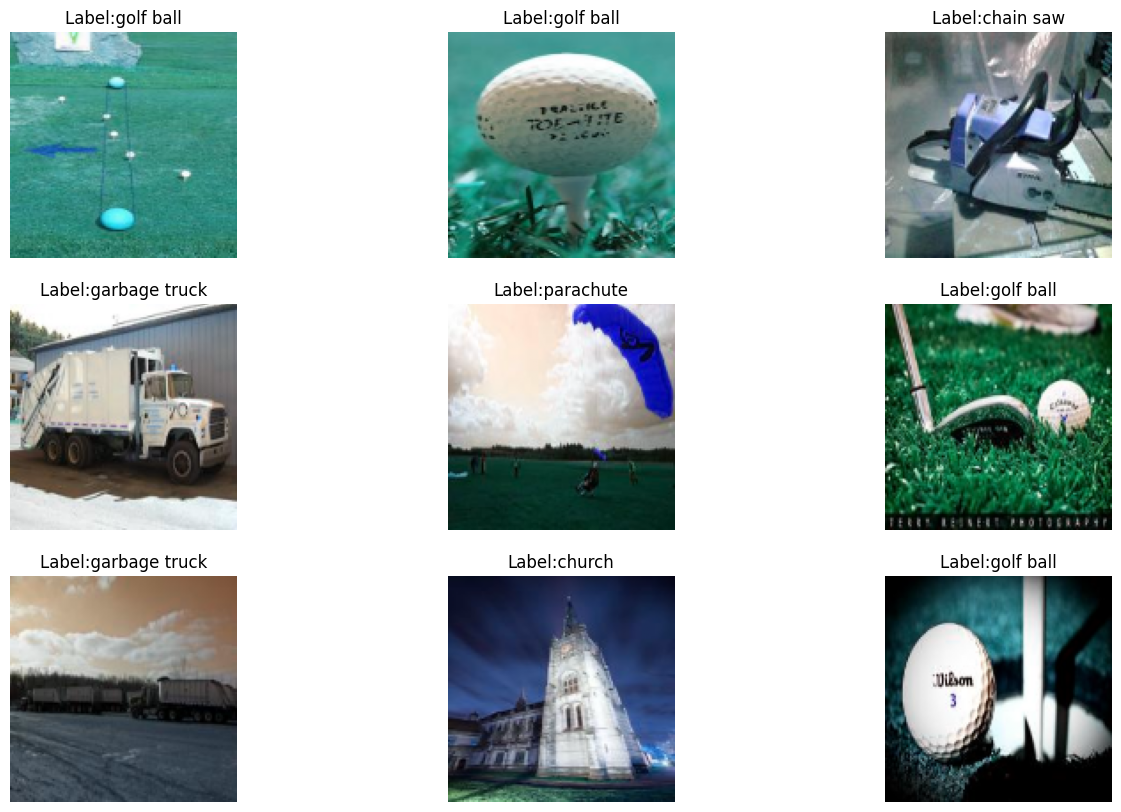

In [8]:
# A list with the names of the image classes
label_names = ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn',  'garbage truck', 'gas pump', 'golf ball', 'parachute']

# Plot a few images to check if the labels make sense
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(0, len(train_images), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(train_images[i[0]])
    plt.title('Label:' + str(label_names[train_labels[i[0]]]))
    plt.axis('off')

In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import vgg16

import datetime
now = datetime.datetime.now

In [10]:
base_model = vgg16.VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Add a global spatial average pooling layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
# Add fully-connected layers
x = Dense(2048, activation='relu')(x)
x = Dropout(0.25)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.25)(x)
# Add a softmax layer with 10 classes
predictions = Dense(10, activation='softmax')(x)

# Create the model
model = Model(inputs=base_model.input, outputs=predictions)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [11]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics = ['accuracy'])

callbacks = [EarlyStopping(monitor='val_loss', patience=5)]

# Fit model
t = now()
history = model.fit(train_images, train_labels, epochs=10, batch_size=64,
                     validation_data=[val_images, val_labels], verbose=1, callbacks=callbacks)
print('Training time: %s' % (now() - t))

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 135s 672ms/step - accuracy: 0.5909 - loss: 1.1879 - val_accuracy: 0.8701 - val_loss: 0.3913
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 345ms/step - accuracy: 0.9069 - loss: 0.3004 - val_accuracy: 0.8962 - val_loss: 0.3147
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 345ms/step - accuracy: 0.9408 - loss: 0.1974 - val_accuracy: 0.9153 - val_loss: 0.3216
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 344ms/step - accuracy: 0.9553 - loss: 0.1435 - val_accuracy: 0.9025 - val_loss: 0.3273
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 344ms/step - accuracy: 0.9670 - loss: 0.1081 - val_accuracy: 0.9210 - val_loss: 0.2791
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 344ms/step - accuracy: 0.9756 - loss: 0.0748 - val_accuracy: 0.8994 - val_loss: 0.3767
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 344ms/step - accuracy: 0.9774 - loss: 0.0663 - val_accuracy: 0.9115 - val_loss: 0.2904
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 344ms/step - accuracy: 0.9781 - loss: 

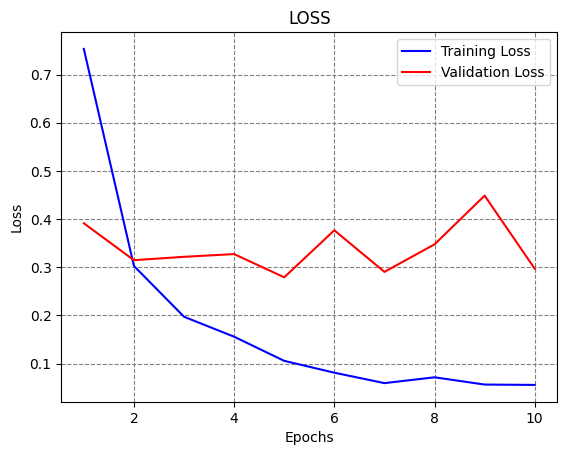

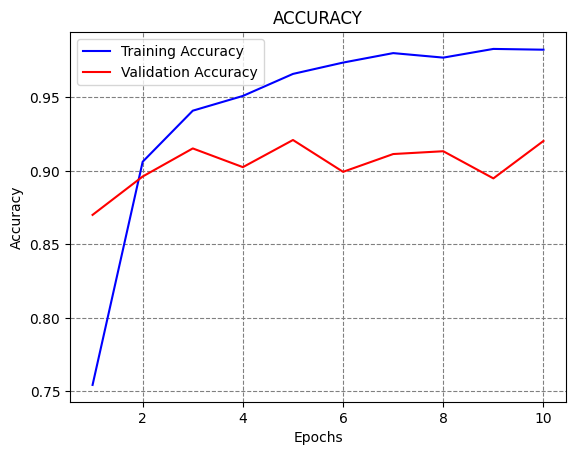

In [12]:
# Plot the loss and accuracy
train_loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochsn = np.arange(1, len(train_loss)+1,1)
plt.plot(epochsn,train_loss, 'b', label='Training Loss')
plt.plot(epochsn,val_loss, 'r', label='Validation Loss')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('LOSS')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.figure()
plt.plot(epochsn, acc, 'b', label='Training Accuracy')
plt.plot(epochsn, val_acc, 'r', label='Validation Accuracy')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('ACCURACY')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [13]:
# Evaluate on test images
evals_test = model.evaluate(test_images, test_labels)
print("Classification Accuracy: ", evals_test[1])

74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.9186 - loss: 0.3142
Classification Accuracy:  0.9133757948875427


# Non-targeted Adversarial Attacks

In [14]:
# Import the TensorFlow Classifier from the ART library
# Import the FastGradientMethod and ProjectedGradientDescent attacks from the ART library
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent

In [15]:
# Create a TensorFlow Classifier object for the model
# State number of classes, input shape, input values (clipped to the range [0, 1]), and loss object
classifier = TensorFlowV2Classifier(model=model, nb_classes=10, input_shape=(128, 128, 3), clip_values=(0, 1),
                                    loss_object=tensorflow.keras.losses.SparseCategoricalCrossentropy())

In [16]:
# Use the first 200 test images for creating adversarial samples
adv_imgs = test_images[0:200]
adv_labels = test_labels[0:200]

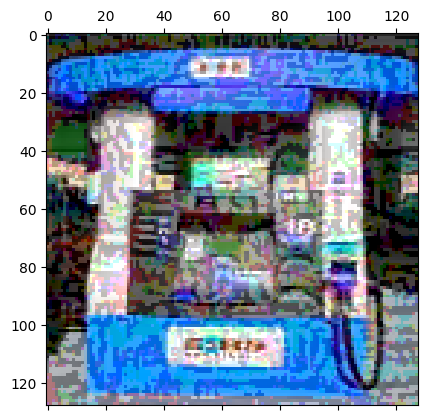

In [17]:
# FGSM attack for the first image with espilon=30./255
attack_fgsm = FastGradientMethod(estimator=classifier, eps=30./255)
fgsm_attack_adv_imgs = attack_fgsm.generate(adv_imgs[0:10])
plt.matshow(np.squeeze(fgsm_attack_adv_imgs[0]))
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 482ms/step - accuracy: 0.2916 - loss: 5.8729
Accuracy on adversarial test data: 28.00%
Average perturbation: 0.04


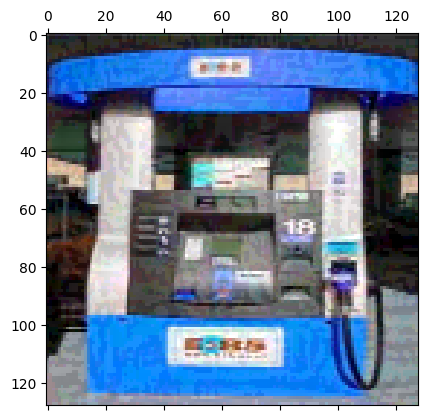

In [18]:
# FGSM attack with espilon=10./155
attack_fgsm = FastGradientMethod(estimator=classifier, eps=10./255)
fgsm_attack_adv_imgs = attack_fgsm.generate(adv_imgs)
loss_test, accuracy_test = model.evaluate(fgsm_attack_adv_imgs, adv_labels)
perturbation = np.mean(np.abs((fgsm_attack_adv_imgs - adv_imgs)))
print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
print('Average perturbation: {:4.2f}'.format(perturbation))
plt.matshow(np.squeeze(fgsm_attack_adv_imgs[0]))
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8881 - loss: 0.4178
Accuracy on adversarial test data: 92.50%
Average perturbation: 0.00


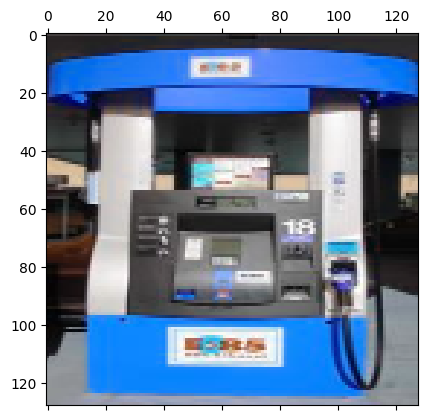

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8249 - loss: 0.6046
Accuracy on adversarial test data: 83.00%
Average perturbation: 0.00


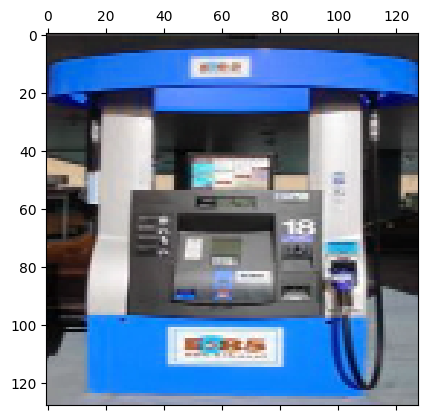

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5065 - loss: 2.6010
Accuracy on adversarial test data: 52.00%
Average perturbation: 0.01


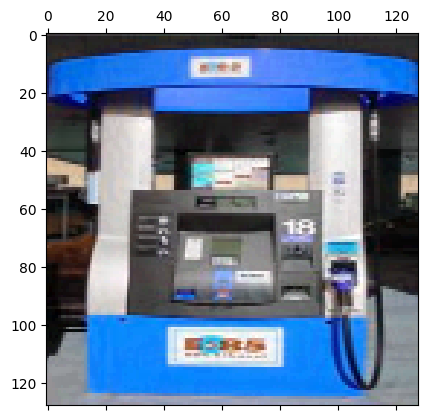

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3899 - loss: 4.2705
Accuracy on adversarial test data: 39.50%
Average perturbation: 0.02


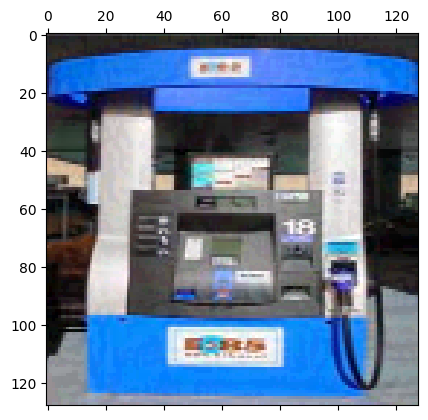

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3061 - loss: 5.5434
Accuracy on adversarial test data: 30.50%
Average perturbation: 0.03


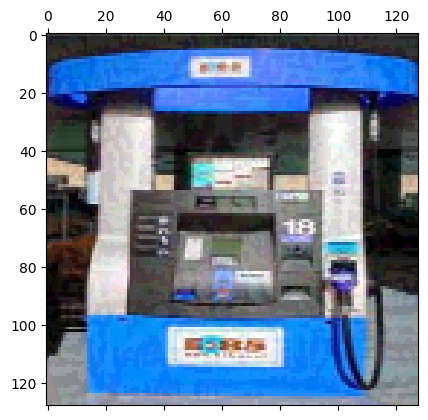

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2483 - loss: 5.6062
Accuracy on adversarial test data: 23.00%
Average perturbation: 0.07


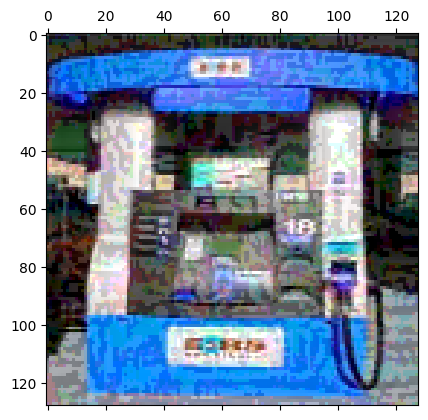

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1965 - loss: 3.2752
Accuracy on adversarial test data: 20.00%
Average perturbation: 0.17


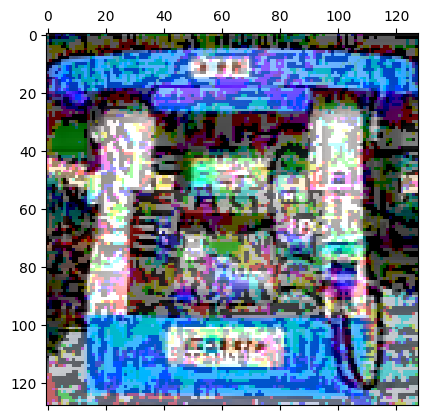

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.1640 - loss: 3.0974
Accuracy on adversarial test data: 16.00%
Average perturbation: 0.26


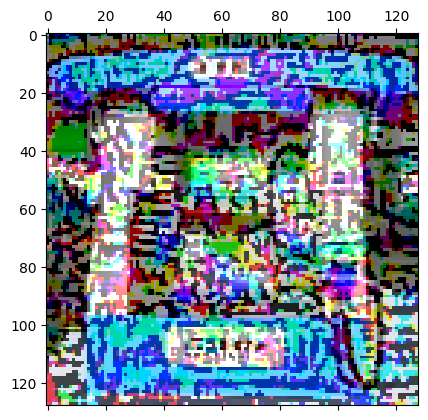

In [19]:
# FGSM attack for various epsilon values
epsilon = [0./255, 1./255, 3./255, 5./255, 8./255, 20./255, 50./255, 80./255]

fgsm_attack_acc = []
for eps in epsilon:
    attack_fgsm = FastGradientMethod(estimator=classifier, eps=eps)
    fgsm_attack_adv_imgs = attack_fgsm.generate(adv_imgs)
    loss_test, accuracy_test = model.evaluate(fgsm_attack_adv_imgs, adv_labels)
    fgsm_attack_acc.append(accuracy_test)
    perturbation = np.mean(np.abs((fgsm_attack_adv_imgs - adv_imgs)))
    print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
    print('Average perturbation: {:4.2f}'.format(perturbation))
    plt.matshow(np.squeeze(fgsm_attack_adv_imgs[0]))
    plt.show()

PGD - Batches: 0it [00:00, ?it/s]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8881 - loss: 0.4178
Accuracy on adversarial test data: 92.50%
Average perturbation: 0.00


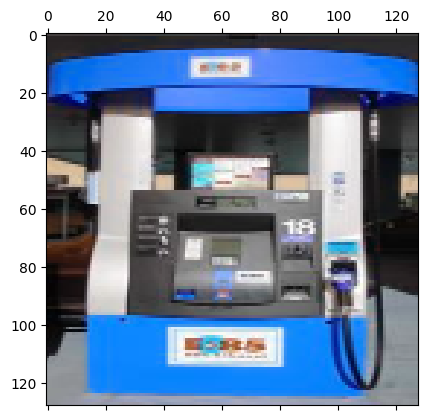

PGD - Batches: 0it [00:00, ?it/s]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7958 - loss: 0.7917
Accuracy on adversarial test data: 80.50%
Average perturbation: 0.00


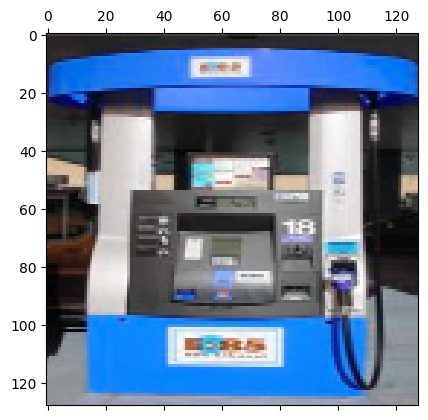

PGD - Batches: 0it [00:00, ?it/s]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4472 - loss: 3.5222
Accuracy on adversarial test data: 45.50%
Average perturbation: 0.01


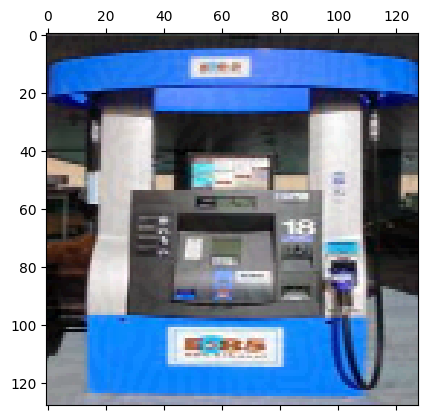

PGD - Batches: 0it [00:00, ?it/s]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3073 - loss: 5.3153
Accuracy on adversarial test data: 29.50%
Average perturbation: 0.02


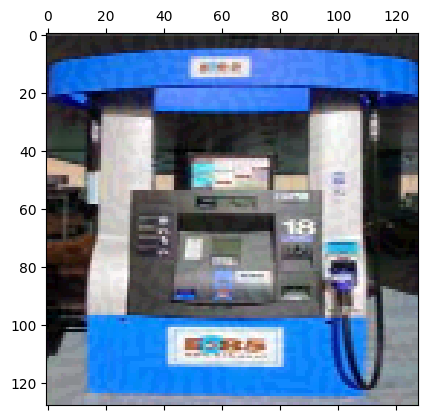

PGD - Batches: 0it [00:00, ?it/s]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2793 - loss: 5.8348
Accuracy on adversarial test data: 27.00%
Average perturbation: 0.03


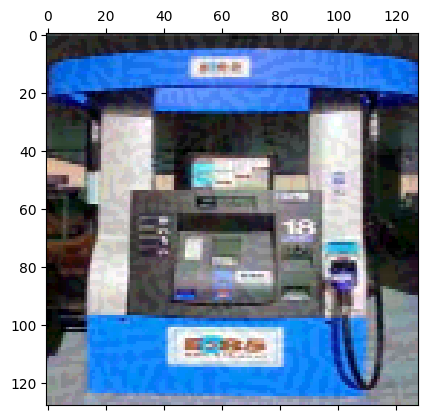

PGD - Batches: 0it [00:00, ?it/s]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1020 - loss: 19.3470
Accuracy on adversarial test data: 6.50%
Average perturbation: 0.06


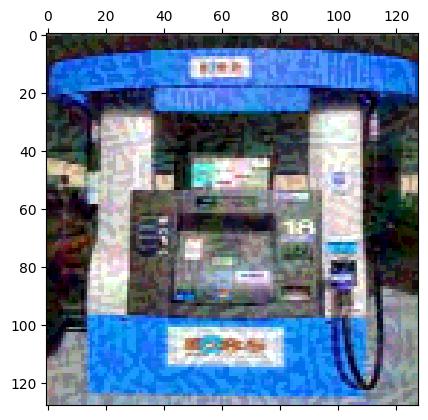

PGD - Batches: 0it [00:00, ?it/s]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.0734 - loss: 65.0707
Accuracy on adversarial test data: 5.00%
Average perturbation: 0.12


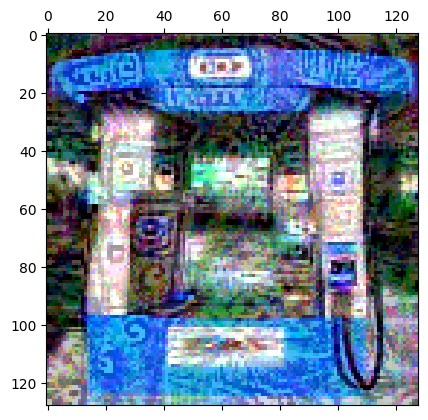

PGD - Batches: 0it [00:00, ?it/s]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.0734 - loss: 94.3012
Accuracy on adversarial test data: 5.00%
Average perturbation: 0.18


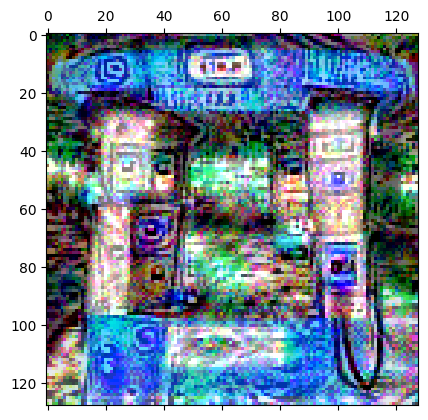

In [20]:
# PGD attack
pgd_attack_acc = []
for eps in epsilon:
    attack_pgd = ProjectedGradientDescent(estimator=classifier, eps=eps, max_iter=20)
    pgd_attack_adv_imgs = attack_pgd.generate(adv_imgs)
    loss_test, accuracy_test = model.evaluate(pgd_attack_adv_imgs, adv_labels)
    pgd_attack_acc.append(accuracy_test)
    perturbation = np.mean(np.abs((pgd_attack_adv_imgs - adv_imgs)))
    print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
    print('Average perturbation: {:4.2f}'.format(perturbation))
    plt.matshow(np.squeeze(pgd_attack_adv_imgs[0]))
    plt.show()

# Targeted Adversarial Attack

Misclassify Church images as Gas Pump images

In [21]:
# Collect all "Church" images from the dataset
church_images_list = []
for i, label in enumerate(test_labels):
  if label==4:
      church_images_list.append(test_images[i])

church_images = np.asarray(church_images_list)

print(church_images.shape)

(249, 128, 128, 3)


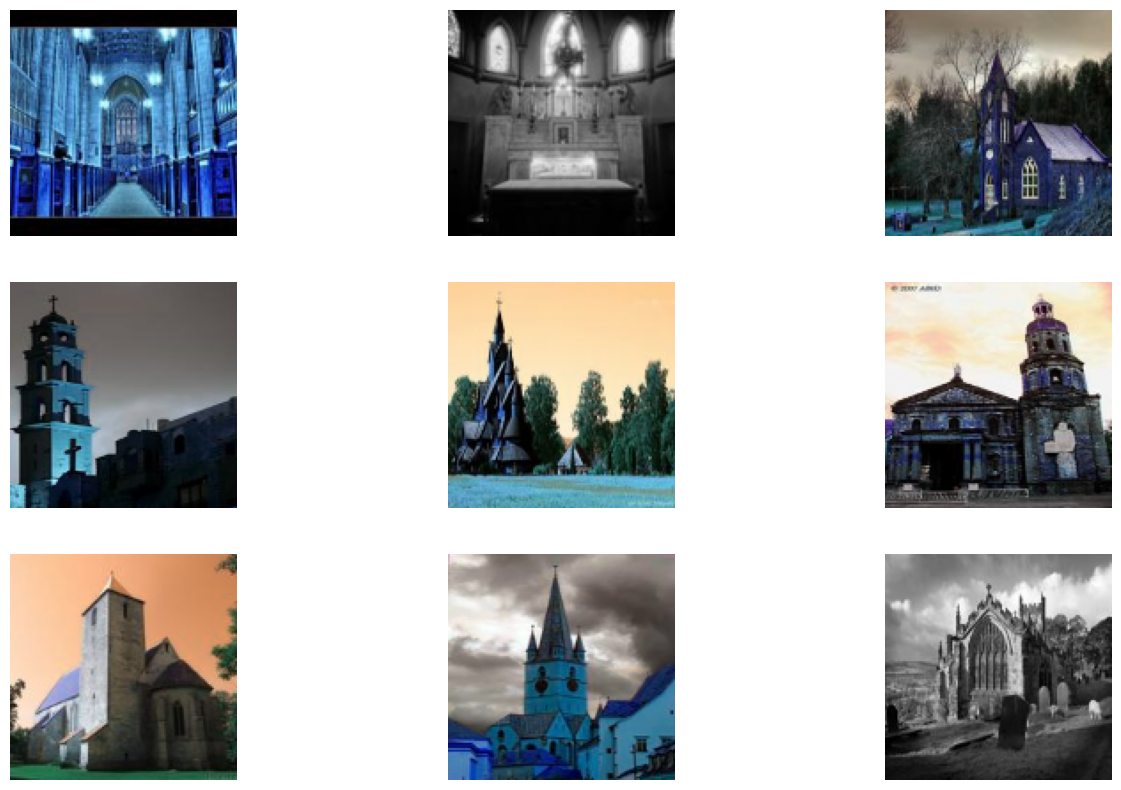

In [22]:
# Plot a few images to check if the labels are accurate
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(0, len(church_images), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(church_images[i[0]])
    plt.axis('off')

In [23]:
# Target labels are "Gas pump" (class label is 7)
labels_target = 7*np.ones((len(church_images),1))

In [24]:
labels_target.shape

(249, 1)

In [25]:
# Church labels
labels_church = 4*np.ones((len(church_images),1))

In [26]:
# Evaluate the accuracy of the model on the set of church images
loss_test, accuracy_test = model.evaluate(np.array(church_images), labels_church)
print('Accuracy on clean test data: {:4.2f}%'.format(accuracy_test * 100))

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 784ms/step - accuracy: 0.9302 - loss: 0.3688
Accuracy on clean test data: 94.78%


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0111 - loss: 12.2778
Accuracy on adversarial test data: 0.80%
Average perturbation: 0.00
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step
Predicted class: [2 4 4 4 9 9 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 9 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 7 4 8 4 4 4 4 4 4 4 4 4 4 4 4 4 7 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 9 4 4 4 4 4 8 4 4
 4 4 4 4 2 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 9 4 4 4 4 5 4 2 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9302 - loss: 0.3688
Accuracy on church labels: 94.78%
Predicted as target labels: 0.80%


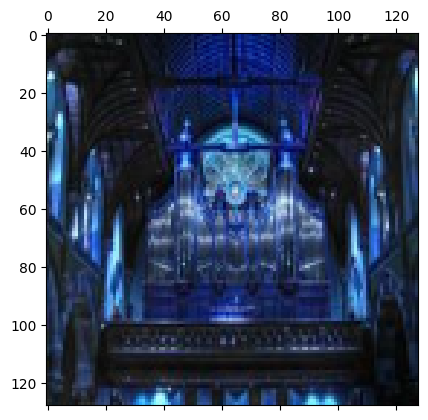

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.0637 - loss: 9.1548
Accuracy on adversarial test data: 5.62%
Average perturbation: 0.00
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: [3 4 4 4 9 0 4 4 7 4 4 4 2 4 7 4 4 4 4 6 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4
 7 4 4 4 4 7 4 4 4 4 4 4 7 4 8 4 4 4 7 4 4 4 4 4 4 4 4 4 7 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 9 4 2 4 4 4 4 4 4 4 4 1 4 4 7 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 7 6 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 2 4 4 2 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 6 4
 4 4 4 4 4 9 4 4 4 4 7 4 4 4 4 4 6 7 4 4 7 4 4 4 4 4 4 4 4 4 4 4 4 4 4 7 2
 4 4 7 4 4 9 8 4 4 4 4 4 2 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8418 - loss: 0.6779
Accuracy on church labels: 85.94%
Predicted as target labels: 5.62%


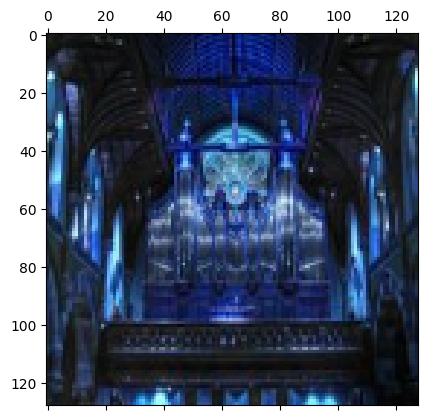

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1786 - loss: 5.6006
Accuracy on adversarial test data: 17.27%
Average perturbation: 0.01
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: [3 6 3 4 9 0 4 7 7 4 9 4 2 2 7 7 4 3 4 6 4 7 4 4 7 4 4 4 4 4 4 3 6 5 3 9 4
 7 4 6 4 9 7 9 4 4 7 4 5 7 4 2 4 8 3 7 8 4 3 7 5 4 4 2 4 7 7 4 4 7 4 9 8 1
 7 2 7 4 4 9 4 4 4 4 4 9 4 2 4 4 4 4 4 6 2 7 1 3 4 7 4 4 4 4 4 4 4 7 4 4 4
 4 4 4 4 8 4 4 4 7 4 2 4 9 4 8 7 7 6 4 5 2 4 3 4 5 7 2 3 4 5 4 4 9 7 4 5 7
 4 2 4 6 2 4 4 7 8 4 7 5 7 5 8 4 4 4 9 5 4 7 4 5 9 4 8 0 4 4 4 4 4 8 6 6 2
 4 7 6 4 2 4 7 7 4 4 7 5 4 4 7 4 6 7 6 4 7 4 8 4 9 4 4 4 4 4 4 7 7 4 4 7 2
 4 4 7 9 9 9 8 9 4 7 4 4 2 7 3 4 4 4 9 2 4 2 4 2 4 4 4]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4672 - loss: 2.7112
Accuracy on church labels: 47.79%
Predicted as target labels: 17.27%


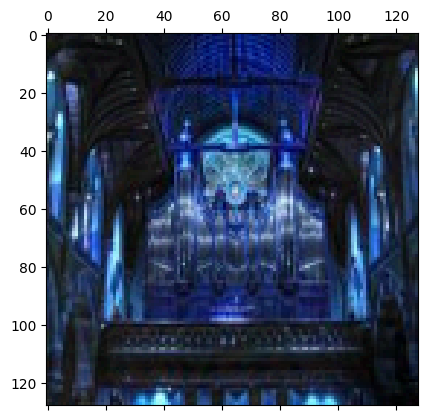

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2311 - loss: 4.4093
Accuracy on adversarial test data: 24.10%
Average perturbation: 0.02
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted class: [7 6 3 4 9 0 4 6 7 4 9 4 2 2 7 7 4 3 4 6 0 7 4 2 7 4 5 0 4 4 4 3 2 5 3 9 4
 7 7 6 3 9 7 9 4 4 7 5 5 7 5 2 4 8 3 7 8 8 3 7 5 4 4 7 9 7 7 4 4 7 4 9 8 1
 7 2 7 4 4 9 9 7 4 9 8 9 4 2 8 7 7 4 7 6 2 7 1 3 8 7 4 4 9 4 4 4 3 7 4 7 9
 4 4 4 4 2 0 4 9 7 9 2 7 9 4 8 7 7 2 8 5 2 9 3 4 5 7 2 3 4 2 2 4 9 7 4 5 7
 4 2 4 2 4 4 4 7 8 4 7 5 7 0 8 4 4 7 9 5 4 7 4 0 3 4 8 0 2 7 3 4 4 7 6 6 2
 7 7 6 4 2 4 7 7 7 2 7 5 4 4 7 9 6 7 6 4 7 4 8 7 9 4 5 4 4 5 4 7 7 4 7 7 2
 4 4 7 9 9 9 8 9 4 7 7 4 2 7 3 8 2 4 3 7 4 2 4 2 4 4 4]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2940 - loss: 4.5717
Accuracy on church labels: 30.12%
Predicted as target labels: 24.10%


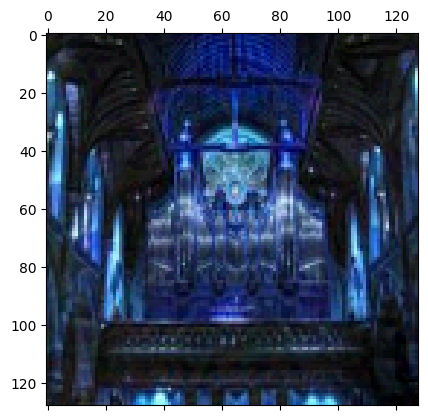

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2876 - loss: 4.0006
Accuracy on adversarial test data: 28.92%
Average perturbation: 0.03
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: [7 6 3 7 9 8 4 7 7 9 9 4 2 2 7 7 4 3 4 6 0 7 4 2 7 7 5 0 4 7 4 3 2 5 3 3 4
 3 8 6 3 9 7 9 9 7 7 5 5 7 5 5 7 8 3 7 8 3 3 7 2 2 4 7 9 7 7 4 9 7 4 9 8 1
 7 2 7 4 4 9 9 7 9 9 8 8 9 2 0 7 7 4 7 6 2 7 1 3 3 7 4 7 3 7 7 4 3 7 9 7 9
 9 9 9 4 2 0 8 9 7 9 0 7 9 3 8 7 7 2 8 5 2 9 3 4 5 7 2 3 4 2 2 4 9 3 4 5 7
 4 2 4 0 4 8 3 7 8 4 7 5 7 0 8 4 4 7 9 5 4 7 4 0 3 4 8 0 2 7 3 7 2 7 7 2 2
 7 7 6 9 2 4 7 7 7 2 7 5 4 7 7 9 6 7 6 4 7 4 8 7 9 7 5 2 3 5 0 7 7 4 7 7 2
 4 7 7 9 9 8 8 9 4 7 7 7 2 2 3 8 2 2 3 7 4 2 7 2 3 5 9]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1580 - loss: 6.1012
Accuracy on church labels: 15.26%
Predicted as target labels: 28.92%


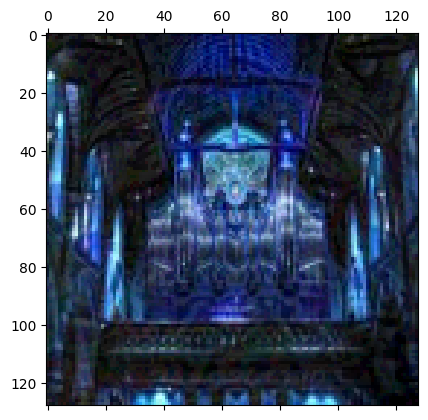

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1493 - loss: 4.3406
Accuracy on adversarial test data: 17.27%
Average perturbation: 0.07
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: [4 3 3 4 9 8 4 3 7 3 9 9 3 2 7 7 3 3 4 3 0 3 4 5 3 6 5 3 3 4 5 3 3 5 3 3 3
 3 8 3 3 3 3 0 9 5 7 5 5 3 5 5 7 8 3 7 8 3 3 0 2 2 4 7 3 7 3 7 9 7 9 9 8 1
 3 5 7 9 3 9 9 7 8 9 8 8 3 6 5 7 3 9 7 3 2 7 1 5 3 7 2 3 3 3 3 4 3 7 9 3 8
 9 8 9 7 5 0 3 9 3 9 0 7 9 3 8 7 7 5 8 5 2 3 3 9 5 7 2 3 4 5 2 9 9 3 4 5 3
 9 7 8 0 4 8 3 3 8 9 7 5 7 0 5 5 4 7 9 5 4 3 9 0 3 5 8 0 2 7 3 3 2 3 3 8 2
 7 3 3 3 2 4 7 3 7 2 7 5 4 5 7 9 3 7 3 5 7 4 8 3 9 7 0 5 3 5 3 7 7 3 3 7 5
 9 7 7 9 0 8 8 3 9 7 3 3 2 2 3 3 9 2 3 7 3 2 7 2 3 5 9]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0860 - loss: 6.4241
Accuracy on church labels: 6.43%
Predicted as target labels: 17.27%


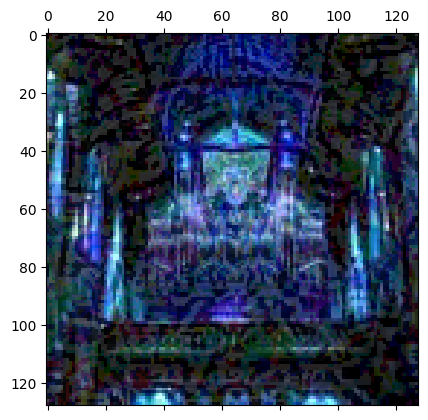

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0134 - loss: 5.2458
Accuracy on adversarial test data: 0.80%
Average perturbation: 0.18
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: [4 4 3 8 8 8 3 8 5 8 9 8 3 5 3 7 3 5 4 8 3 3 4 5 3 3 5 3 4 4 8 3 8 5 3 5 3
 8 4 3 3 8 5 5 3 5 4 5 3 3 8 5 4 8 3 3 8 8 3 8 5 9 4 5 8 4 3 4 3 8 9 8 8 8
 3 8 3 3 8 9 9 8 5 3 9 3 3 4 5 4 8 4 4 3 8 5 3 5 8 7 4 4 8 3 8 4 8 3 4 4 4
 9 8 8 9 5 3 3 4 3 9 3 3 9 4 8 8 3 5 3 8 5 9 8 9 8 3 5 8 3 8 3 9 3 8 4 5 5
 3 3 8 5 5 3 8 3 8 9 3 5 8 4 5 8 4 3 9 3 4 3 8 8 3 5 8 8 3 3 4 4 5 3 3 9 4
 5 8 3 9 5 4 3 3 4 3 3 3 4 4 4 8 9 3 3 5 5 4 8 3 8 3 5 5 4 5 3 3 3 4 8 3 5
 9 4 4 8 8 8 8 3 4 3 3 3 3 3 5 3 4 4 3 5 3 4 3 3 5 3 3]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1734 - loss: 2.7925
Accuracy on church labels: 18.07%
Predicted as target labels: 0.80%


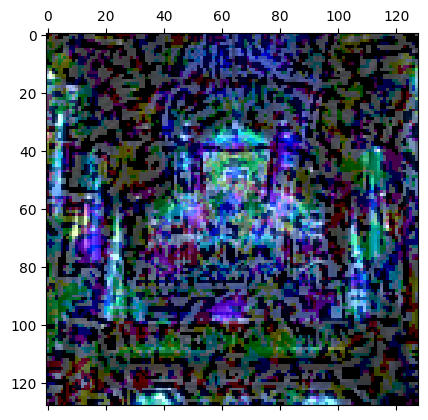

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0000e+00 - loss: 5.0156
Accuracy on adversarial test data: 0.00%
Average perturbation: 0.26
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: [8 4 4 8 8 8 3 8 8 8 3 8 8 4 8 4 4 8 4 8 8 8 8 5 8 8 8 3 4 5 8 8 8 4 8 4 5
 8 4 3 8 8 8 8 8 8 8 8 8 3 8 5 8 8 8 3 9 8 8 4 8 9 4 8 8 4 8 4 8 8 8 8 8 8
 3 8 8 4 8 8 8 8 8 8 9 8 8 4 8 4 8 4 4 8 8 8 8 8 8 4 4 4 8 8 8 4 4 8 4 8 4
 8 8 8 4 5 4 5 4 8 9 8 8 3 4 8 8 8 8 4 4 8 9 8 9 8 8 5 8 8 8 4 8 8 8 4 8 5
 8 9 8 8 5 8 8 3 8 9 4 8 9 4 5 4 4 3 8 8 4 8 4 4 8 5 8 8 3 4 4 4 8 8 3 8 8
 8 8 8 9 8 8 4 4 4 8 8 8 4 4 4 8 8 8 8 8 4 4 4 8 8 8 5 4 4 5 8 8 8 4 8 8 4
 8 4 4 8 4 8 8 8 4 8 8 3 8 8 8 4 4 4 8 8 4 4 8 8 5 8 8]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2312 - loss: 1.7313
Accuracy on church labels: 26.51%
Predicted as target labels: 0.00%


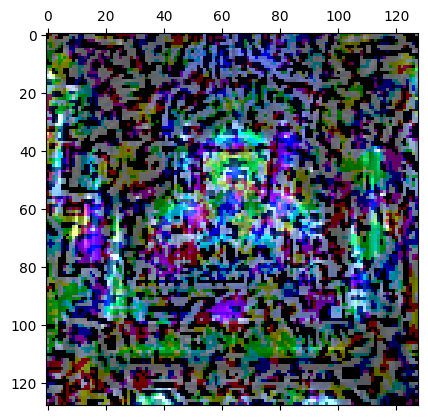

In [27]:
 # FGSM targetted attack

epsilon = [0./255, 1./255, 3./255, 5./255, 8./255, 20./255, 50./255, 80./255]

fgsm_target_attack_acc = []

for eps in epsilon:
    attack_fgsm_tar = FastGradientMethod(estimator=classifier, eps=eps, targeted=True)
    fgsm_attack_adv_imgs_tar = attack_fgsm_tar.generate(church_images, labels_target)
    loss_test, accuracy_test = model.evaluate(fgsm_attack_adv_imgs_tar, labels_target)
    fgsm_target_attack_acc.append(accuracy_test)
    perturbation = np.mean(np.abs((fgsm_attack_adv_imgs_tar - church_images)))
    print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
    print('Average perturbation: {:4.2f}'.format(perturbation))

    preds = model.predict(fgsm_attack_adv_imgs_tar)
    print('Predicted class:', np.argmax(preds, axis=-1))

    loss_test, accuracy_test = model.evaluate(fgsm_attack_adv_imgs_tar, labels_church)
    print('Accuracy on church labels: {:4.2f}%'.format(accuracy_test * 100))

    print('Predicted as target labels: {:4.2f}%'.format(100*np.sum(np.argmax(preds, axis=-1)==7)/len(labels_target)))

    plt.matshow(np.squeeze(fgsm_attack_adv_imgs_tar[0]))
    plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0111 - loss: 12.2778
Accuracy on adversarial test data: 0.80%
Average perturbation: 0.00
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: [2 4 4 4 9 9 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 9 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 7 4 8 4 4 4 4 4 4 4 4 4 4 4 4 4 7 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 9 4 4 4 4 4 8 4 4
 4 4 4 4 2 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 9 4 4 4 4 5 4 2 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9302 - loss: 0.3688
Accuracy on church labels: 94.78%
Predicted as target labels: 0.80%
**********


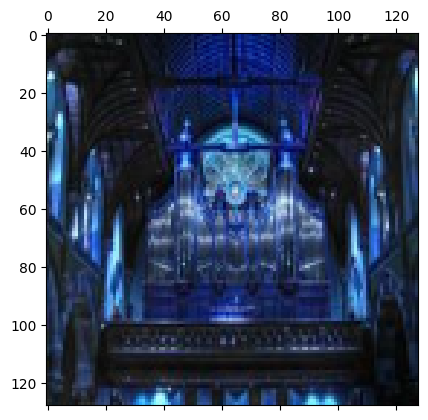

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0520 - loss: 9.0916
Accuracy on adversarial test data: 5.22%
Average perturbation: 0.00
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: [4 4 4 4 9 9 4 4 7 4 4 4 4 4 4 4 4 4 4 4 4 4 9 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 7 4 4 4 4 4 4 7 4 8 4 4 4 7 4 4 4 4 4 4 4 4 4 7 7 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 7 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 7 4 4 4 4 4 4 4 4 4 4 4 9 4 4 4 4 4 8 4 4
 4 4 4 4 2 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 9 4 4 4 4 7 4 2 4 4 4 6 7 4 4 7 4 4 4 4 4 4 4 4 4 4 4 4 4 4 7 4
 4 4 7 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8991 - loss: 0.4936
Accuracy on church labels: 90.76%
Predicted as target labels: 5.22%
**********


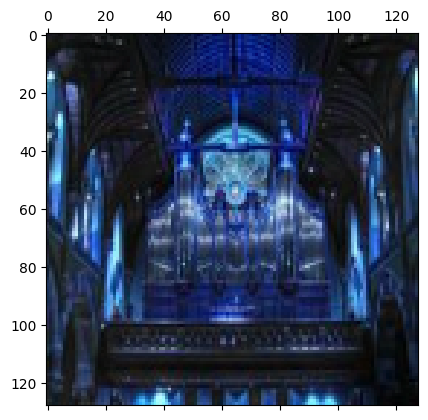

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1616 - loss: 5.2531
Accuracy on adversarial test data: 17.27%
Average perturbation: 0.01
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted class: [4 4 4 4 9 9 4 4 7 4 4 4 4 4 7 7 4 4 4 7 4 4 9 4 7 4 4 4 4 4 4 4 4 4 3 4 4
 4 4 4 4 4 7 4 4 4 7 4 3 7 4 8 4 4 4 7 8 4 4 4 4 4 4 4 4 7 7 4 4 4 4 9 4 4
 4 4 7 4 4 9 4 4 4 4 4 4 4 4 4 4 4 4 4 4 7 7 3 4 4 7 4 4 4 7 4 4 4 7 4 7 4
 4 4 4 4 4 4 4 4 7 4 4 7 9 4 4 4 7 7 4 4 4 4 7 4 4 4 4 4 9 4 4 4 4 7 8 4 7
 4 4 4 4 2 4 4 4 4 4 7 4 7 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 7 4 4 4 4 7 4 4 4
 4 7 4 4 4 9 7 7 7 4 7 4 2 4 7 4 4 7 4 4 7 4 4 4 4 4 4 4 4 4 4 7 7 4 4 7 4
 4 4 7 4 4 4 4 4 4 7 4 4 4 4 4 4 4 4 4 7 4 4 4 4 4 4 4]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7552 - loss: 0.9898
Accuracy on church labels: 76.31%
Predicted as target labels: 17.27%
**********


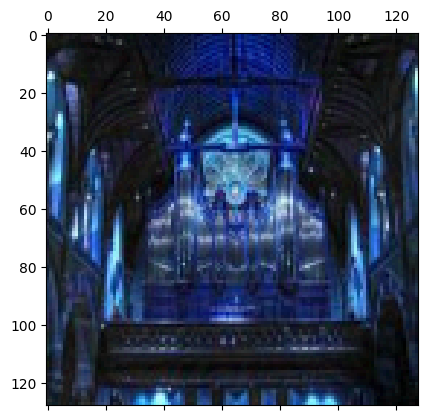

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.2265 - loss: 4.4818
Accuracy on adversarial test data: 23.69%
Average perturbation: 0.02
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted class: [4 4 4 7 9 9 4 4 7 4 4 4 4 4 7 7 4 4 4 7 4 7 9 4 7 7 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 7 4 4 7 4 4 4 7 4 8 4 4 4 7 4 7 4 4 4 4 4 4 4 7 7 4 4 4 4 4 4 2
 4 4 4 4 4 4 4 7 4 4 4 4 4 4 4 4 4 4 7 7 7 7 4 4 4 7 4 4 4 4 4 4 7 7 4 4 4
 4 7 4 4 4 4 4 4 4 4 4 4 4 4 4 7 7 7 7 4 7 4 7 4 2 4 4 7 9 4 4 4 4 7 8 4 7
 4 7 4 4 2 4 7 4 4 4 7 4 7 4 7 4 4 7 4 4 4 4 4 4 4 4 4 4 4 7 4 4 4 4 4 4 7
 7 7 4 7 4 7 4 7 7 4 7 4 4 4 4 4 7 7 7 4 4 4 8 4 4 4 4 4 4 4 4 4 7 4 7 4 7
 4 4 7 4 4 4 4 4 7 7 4 4 4 4 4 4 4 4 4 7 4 4 4 4 4 7 4]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7206 - loss: 1.1996
Accuracy on church labels: 72.29%
Predicted as target labels: 23.69%
**********


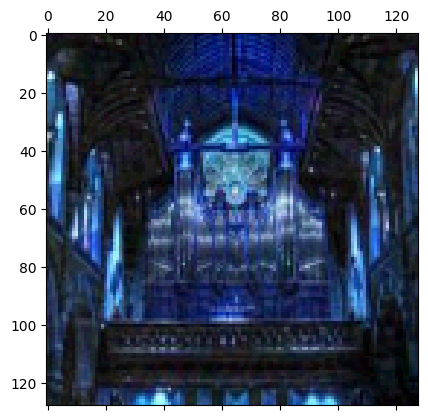

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2171 - loss: 4.9271
Accuracy on adversarial test data: 26.10%
Average perturbation: 0.03
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: [3 7 4 4 9 3 4 4 7 4 4 4 4 4 7 4 4 4 4 7 4 4 9 4 4 4 4 4 4 4 4 5 7 4 3 7 4
 4 4 6 4 4 7 4 4 4 4 4 4 7 4 5 4 4 4 7 4 4 4 4 4 4 7 4 4 7 4 4 4 4 4 4 4 4
 7 4 7 4 4 4 4 7 4 4 4 6 4 7 7 4 4 4 7 7 7 4 7 4 4 7 4 7 4 7 4 4 7 7 7 7 4
 4 4 4 7 4 4 3 4 4 4 4 4 4 4 4 7 7 7 7 4 4 4 4 2 7 7 4 7 9 4 4 4 4 4 4 4 4
 4 7 4 4 2 4 4 7 4 7 7 4 7 4 7 4 4 7 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 7 4 4 4
 4 4 4 4 4 7 4 4 7 4 7 4 7 7 4 4 7 7 7 4 7 4 4 4 4 7 4 4 4 4 4 4 7 4 7 4 4
 4 4 7 4 4 4 4 4 4 7 4 7 7 4 7 4 7 4 3 7 7 4 4 7 7 4 4]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6951 - loss: 1.4443
Accuracy on church labels: 67.87%
Predicted as target labels: 26.10%
**********


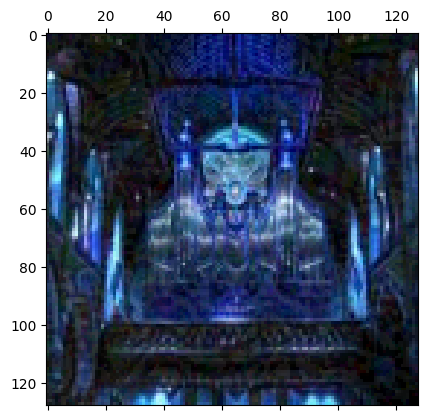

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9271 - loss: 0.3635
Accuracy on adversarial test data: 93.17%
Average perturbation: 0.06
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted class: [7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 4 7 7 7 7 7 7 7 7 7 4 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 5 0 7 7 7 7 7 7 7 7 7 7 7 7 7 4 7 7 7 7 7 4 7 7 7 7 7 7
 7 7 7 4 4 7 7 7 7 7 7 7 7 7 7 7 7 4 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 4 7 7 7 7 9 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 4 7 7 7 7 7 4 7 7 7 7 7 7 4 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 4 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 4 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 0 7 7 7]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0565 - loss: 13.6113
Accuracy on church labels: 5.22%
Predicted as target labels: 93.17%
**********


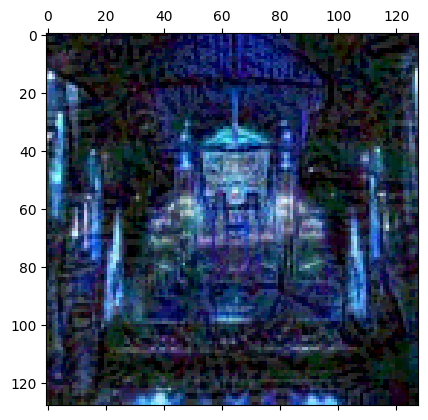

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8500 - loss: 0.5301
Accuracy on adversarial test data: 85.94%
Average perturbation: 0.11
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: [7 7 7 7 7 3 7 7 7 4 7 7 7 7 7 7 3 7 7 7 3 7 7 7 7 7 3 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 4 7 7 4 3 7 7 7 7 3 4 7 4 7 7 7 3 7 7 7 7 7 7 7 7 7 7 7 7 7 7 3
 7 7 7 7 7 7 7 7 7 7 7 7 7 3 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 4 7 7
 8 4 7 7 7 5 4 4 7 7 7 7 7 3 8 7 7 7 7 7 3 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 3 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 3 3 7 7 7 7 7 7 7 7 7 7 7 3 7 7 4 7 7 3 7 3 7
 3 7 7 7 7 7 7 7 4 7 4 7 7 7 7 7 7 4 4 7 7 7 7 7 7 7 7]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0547 - loss: 16.6772
Accuracy on church labels: 5.62%
Predicted as target labels: 85.94%
**********


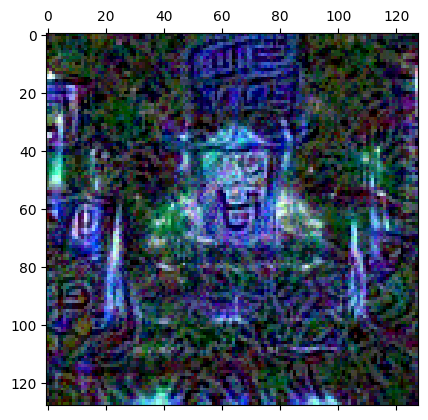

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9775 - loss: 0.0476
Accuracy on adversarial test data: 98.39%
Average perturbation: 0.17
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: [7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 3 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 4 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 4 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 4 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7]
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0126 - loss: 23.4506
Accuracy on church labels: 1.20%
Predicted as target labels: 98.39%
**********


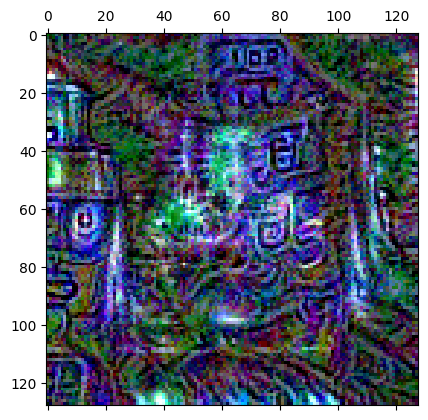

Training time: 0:35:40.423754


In [28]:
# PGD targetted attack
pgd_target_attack_acc = []
for eps in epsilon:
    attack_pgd_tar = ProjectedGradientDescent(estimator=classifier, eps=eps, targeted=True, verbose=False)
    pgd_attack_adv_imgs_tar = attack_pgd_tar.generate(church_images, labels_target)
    loss_test, accuracy_test = model.evaluate(pgd_attack_adv_imgs_tar, labels_target)
    pgd_target_attack_acc.append(accuracy_test)
    perturbation = np.mean(np.abs((pgd_attack_adv_imgs_tar - church_images)))

    print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
    print('Average perturbation: {:4.2f}'.format(perturbation))

    preds = model.predict(pgd_attack_adv_imgs_tar)
    print('Predicted class:', np.argmax(preds, axis=-1))

    loss_test, accuracy_test = model.evaluate(pgd_attack_adv_imgs_tar, labels_church)
    print('Accuracy on church labels: {:4.2f}%'.format(accuracy_test * 100))

    print('Predicted as target labels: {:4.2f}%'.format(100*np.sum(np.argmax(preds, axis=-1)==7)/len(labels_target)))

    print(10*'*')

    plt.matshow(np.squeeze(pgd_attack_adv_imgs_tar[0]))
    plt.show()

print('Training time: %s' % (now() - t))